In [1]:
import sqlite3
import pandas as pd


In [2]:
connection = sqlite3.connect(
    "../data/datapulse.db"
)

In [3]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

pd.read_sql_query(
    query,
    connection
)

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [4]:
query = """
CREATE TABLE IF NOT EXISTS customer_summary AS

SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(quantity) AS total_units,
    SUM(net_sales) AS total_revenue,
    AVG(net_sales) AS average_transaction_value,
    AVG(discount) AS average_discount,
    MIN(order_date) AS first_purchase_date,
    MAX(order_date) AS last_purchase_date

FROM sales

GROUP BY customer_id;
"""

In [5]:
connection.execute(query)
connection.commit()

In [6]:
query = """
SELECT *
FROM customer_summary
LIMIT 10;
"""

customer_summary = pd.read_sql_query(
    query,
    connection
)

customer_summary

,customer_id,total_orders,total_units,total_revenue,average_transaction_value,average_discount,first_purchase_date,last_purchase_date
0,C0001,7,20,135820.0,19402.857143,0.078571,2025-01-16 16:46:45.681136,2026-05-16 15:04:30.054010
1,C0002,9,24,300600.0,33400.000000,0.094444,2025-02-15 11:05:24.784956,2026-06-17 16:19:58.319663
2,C0003,13,35,878500.0,67576.923077,0.065385,2025-01-01 15:41:56.903380,2026-06-12 21:12:21.028205
3,C0004,16,43,1108185.0,69261.562500,0.093750,2025-02-05 23:27:09.685937,2026-05-05 09:34:23.212642
4,C0005,4,9,100500.0,25125.000000,0.075000,2025-05-30 21:43:10.358071,2026-06-04 19:34:59.219843
5,C0006,6,14,193350.0,32225.000000,0.091667,2025-04-16 12:47:40.412082,2026-05-28 04:25:35.347069
6,C0007,7,13,191625.0,27375.000000,0.035714,2025-01-28 08:44:50.458091,2026-05-21 12:49:06.829365
7,C0008,6,19,488550.0,81425.000000,0.125000,2025-02-07 19:56:00.912182,2026-06-08 20:23:40.124024
8,C0009,8,24,358275.0,44784.375000,0.075000,2025-04-04 02:30:39.247849,2026-06-25 20:34:19.611922
9,C0010,7,20,609875.0,87125.000000,0.085714,2025-02-11 18:07:42.332466,2026-05-20 23:44:09.409881


In [7]:
query = """
SELECT
    s.order_id,
    s.customer_id,
    s.product,
    s.net_sales,
    c.total_orders,
    c.total_revenue

FROM sales AS s

INNER JOIN customer_summary AS c
    ON s.customer_id = c.customer_id

LIMIT 10;
"""

In [8]:
joined_data = pd.read_sql_query(
    query,
    connection
)

joined_data

,order_id,customer_id,product,net_sales,total_orders,total_revenue
0,O00001,C0017,Headphones,7500.0,9,539200.0
1,O00002,C0056,Monitor,60000.0,15,732600.0
2,O00003,C0182,Laptop,123500.0,11,766815.0
3,O00004,C0144,Laptop,175500.0,9,408725.0
4,O00005,C0319,Laptop,65000.0,12,901250.0
5,O00006,C0358,Keyboard,3800.0,10,324075.0
6,O00007,C0003,Smartphone,40000.0,13,878500.0
7,O00008,C0202,Mouse,3800.0,10,668025.0
8,O00009,C0101,Laptop,61750.0,10,613375.0
9,O00010,C0163,Monitor,75000.0,10,904050.0


In [10]:
# Q) What is each customer's total revenue?
query = """
SELECT
    customer_id,
    total_orders,
    total_units,
    total_revenue

FROM customer_summary

ORDER BY total_revenue DESC

LIMIT 10;
"""

top_customers = pd.read_sql_query(
    query,
    connection
)

top_customers


,customer_id,total_orders,total_units,total_revenue
0,C0410,15,56,1526130.0
1,C0127,13,42,1523575.0
2,C0307,11,36,1475130.0
3,C0159,22,65,1382975.0
4,C0215,13,48,1382075.0
5,C0300,14,41,1355175.0
6,C0456,20,60,1319975.0
7,C0050,12,43,1281650.0
8,C0275,15,52,1266725.0
9,C0102,14,47,1261750.0


In [11]:
# Q) Top 10 Customers
top_customers

,customer_id,total_orders,total_units,total_revenue
0,C0410,15,56,1526130.0
1,C0127,13,42,1523575.0
2,C0307,11,36,1475130.0
3,C0159,22,65,1382975.0
4,C0215,13,48,1382075.0
5,C0300,14,41,1355175.0
6,C0456,20,60,1319975.0
7,C0050,12,43,1281650.0
8,C0275,15,52,1266725.0
9,C0102,14,47,1261750.0


In [12]:
# Q) Which customers generated more than ₹50,000?
query = """
SELECT
    customer_id,
    total_orders,
    total_revenue

FROM customer_summary

WHERE total_revenue > 50000

ORDER BY total_revenue DESC;
"""

high_value_customers = pd.read_sql_query(
    query,
    connection
)

high_value_customers

,customer_id,total_orders,total_revenue
0,C0410,15,1526130.0
1,C0127,13,1523575.0
2,C0307,11,1475130.0
3,C0159,22,1382975.0
4,C0215,13,1382075.0
...,...,...,...
492,C0220,7,79190.0
493,C0022,5,76675.0
494,C0169,9,68175.0
495,C0214,5,59620.0


In [13]:
# Count High-Value Customers
high_value_customer_count = len(
    high_value_customers
)

total_customer_count = pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_customers
    FROM customer_summary;
    """,
    connection
).loc[0, "total_customers"]

In [14]:
high_value_customer_pct = (
    high_value_customer_count
    / total_customer_count
    * 100
)

In [15]:
print(
    "High-Value Customers:",
    high_value_customer_count
)

print(
    "Percentage of Customers:",
    round(high_value_customer_pct, 2),
    "%"
)

High-Value Customers: 497
Percentage of Customers: 99.4 %


In [16]:
# Q) How much revenue comes from high-value customers?
query = """
SELECT
    SUM(total_revenue) AS high_value_revenue

FROM customer_summary

WHERE total_revenue > 50000;
"""

high_value_revenue = pd.read_sql_query(
    query,
    connection
).loc[0, "high_value_revenue"]

In [17]:
total_customer_revenue = pd.read_sql_query(
    """
    SELECT SUM(total_revenue) AS total_revenue
    FROM customer_summary;
    """,
    connection
).loc[0, "total_revenue"]

In [18]:
high_value_revenue_pct = (
    high_value_revenue
    / total_customer_revenue
    * 100
)

In [19]:
print(
    f"High-Value Customer Revenue: "
    f"₹{high_value_revenue:,.2f}"
)

print(
    "Revenue Contribution:",
    round(high_value_revenue_pct, 2),
    "%"
)

High-Value Customer Revenue: ₹278,972,085.00
Revenue Contribution: 99.96 %


In [20]:
# Product Summary Table
query = """
CREATE TABLE IF NOT EXISTS product_summary AS

SELECT
    product,
    category,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(quantity) AS total_units,
    SUM(net_sales) AS total_revenue,
    AVG(unit_price) AS average_unit_price,
    AVG(discount) AS average_discount

FROM sales

GROUP BY
    product,
    category;
"""

In [21]:
connection.execute(query)
connection.commit()

In [22]:
query = """
SELECT *
FROM product_summary;
"""

product_summary = pd.read_sql_query(
    query,
    connection
)

product_summary

,product,category,total_orders,total_units,total_revenue,average_unit_price,average_discount
0,Headphones,Accessories,633,1873,4321375.0,2500.0,0.077725
1,Keyboard,Accessories,612,1835,3398100.0,2000.0,0.074755
2,Laptop,Electronics,639,1917,115261250.0,65000.0,0.075822
3,Monitor,Electronics,651,1928,26736750.0,15000.0,0.073502
4,Mouse,Accessories,598,1769,1307200.0,800.0,0.075000
5,Smartphone,Electronics,649,1944,71852000.0,40000.0,0.077504
6,Tablet,Electronics,602,1791,50097000.0,30000.0,0.069601
7,Webcam,Accessories,616,1894,6120625.0,3500.0,0.075974


In [23]:
# Customer + Sales + Product
query = """
SELECT
    s.order_id,
    s.customer_id,
    s.product,
    p.category,
    s.region,
    s.net_sales,
    c.total_orders AS customer_total_orders,
    c.total_revenue AS customer_total_revenue

FROM sales AS s

INNER JOIN customer_summary AS c
    ON s.customer_id = c.customer_id

INNER JOIN product_summary AS p
    ON s.product = p.product

LIMIT 20;
"""

In [24]:
three_table_join = pd.read_sql_query(
    query,
    connection
)

three_table_join

,order_id,customer_id,product,category,region,net_sales,customer_total_orders,customer_total_revenue
0,O00001,C0017,Headphones,Accessories,North,7500.0,9,539200.0
1,O00002,C0056,Monitor,Electronics,East,60000.0,15,732600.0
2,O00003,C0182,Laptop,Electronics,North,123500.0,11,766815.0
3,O00004,C0144,Laptop,Electronics,East,175500.0,9,408725.0
4,O00005,C0319,Laptop,Electronics,West,65000.0,12,901250.0
5,O00006,C0358,Keyboard,Accessories,North,3800.0,10,324075.0
6,O00007,C0003,Smartphone,Electronics,West,40000.0,13,878500.0
7,O00008,C0202,Mouse,Accessories,West,3800.0,10,668025.0
8,O00009,C0101,Laptop,Electronics,South,61750.0,10,613375.0
9,O00010,C0163,Monitor,Electronics,South,75000.0,10,904050.0


In [25]:
query = """
SELECT
    COUNT(*) AS row_count

FROM sales AS s

INNER JOIN customer_summary AS c
    ON s.customer_id = c.customer_id;
"""

inner_count = pd.read_sql_query(
    query,
    connection
)

inner_count

,row_count
0,5000


In [26]:
# Left join
query = """
SELECT
    COUNT(*) AS row_count

FROM sales AS s

LEFT JOIN customer_summary AS c
    ON s.customer_id = c.customer_id;
"""

left_count = pd.read_sql_query(
    query,
    connection
)

left_count

,row_count
0,5000


In [27]:
# unmatched records
query = """
SELECT
    COUNT(*) AS unmatched_rows

FROM sales AS s

LEFT JOIN customer_summary AS c
    ON s.customer_id = c.customer_id

WHERE c.customer_id IS NULL;
"""

unmatched = pd.read_sql_query(
    query,
    connection
)

unmatched

,unmatched_rows
0,0


In [28]:
# Customer Revenue Distribution
query = """
SELECT
    MIN(total_revenue) AS minimum_revenue,
    AVG(total_revenue) AS average_revenue,
    MAX(total_revenue) AS maximum_revenue

FROM customer_summary;
"""

customer_revenue_stats = pd.read_sql_query(
    query,
    connection
)

customer_revenue_stats

,minimum_revenue,average_revenue,maximum_revenue
0,35190.0,558188.6,1526130.0


In [29]:
# Repeat Customers Using SQL
query = """
SELECT
    COUNT(*) AS repeat_customers

FROM customer_summary

WHERE total_orders > 1;
"""

repeat_customers = pd.read_sql_query(
    query,
    connection
).loc[0, "repeat_customers"]

In [30]:
repeat_customer_rate = (
    repeat_customers
    / total_customer_count
    * 100
)

In [31]:
print(
    "Repeat Customers:",
    int(repeat_customers)
)

print(
    "Repeat Customer Rate:",
    round(repeat_customer_rate, 2),
    "%"
)

Repeat Customers: 500
Repeat Customer Rate: 100.0 %


In [32]:
# the Top 10% Customers
query = """
SELECT
    customer_id,
    total_revenue

FROM customer_summary

ORDER BY total_revenue DESC;
"""

customer_ranking = pd.read_sql_query(
    query,
    connection
)

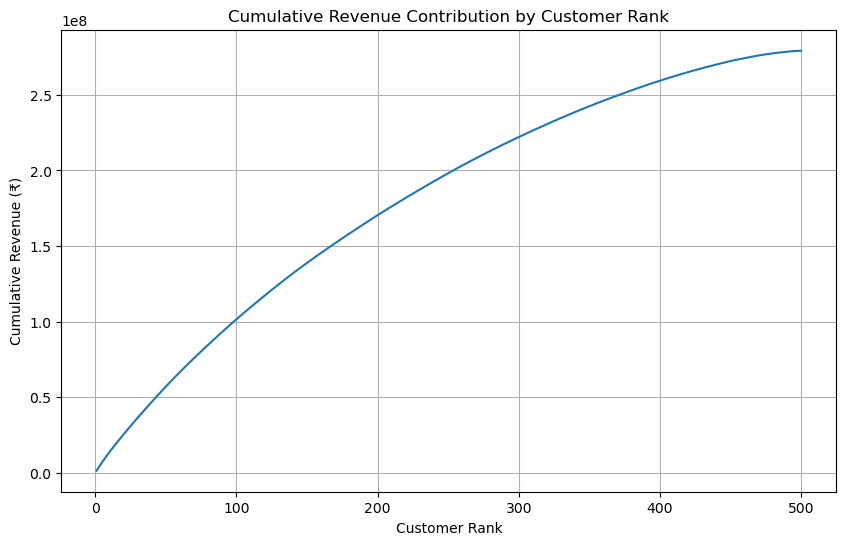

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(customer_ranking) + 1),
    customer_ranking["total_revenue"].cumsum()
)

plt.title(
    "Cumulative Revenue Contribution by Customer Rank"
)

plt.xlabel(
    "Customer Rank"
)

plt.ylabel(
    "Cumulative Revenue (₹)"
)

plt.grid()

plt.show()

In [36]:
# Insights
print("=" * 70)
print("📊 DATAPULSE — DAY 18 SQL JOIN & CUSTOMER INSIGHTS")
print("=" * 70)

print(
    f"\n1. CUSTOMER BASE:"
    f"\nDataPulse contains "
    f"{int(total_customer_count):,} unique customers."
)

print(
    f"\n2. REPEAT CUSTOMERS:"
    f"\n{int(repeat_customers):,} customers made more than "
    f"one order."
)

print(
    f"\nRepeat Customer Rate:"
    f" {repeat_customer_rate:.2f}%."
)

print(
    f"\n3. HIGH-VALUE CUSTOMERS:"
    f"\n{high_value_customer_count:,} customers generated "
    f"more than ₹50,000 in historical revenue."
)

print(
    f"\nThey represent "
    f"{high_value_customer_pct:.2f}% of the customer base."
)

print(
    f"\n4. HIGH-VALUE REVENUE:"
    f"\nThese customers generated "
    f"₹{high_value_revenue:,.2f}, representing "
    f"{high_value_revenue_pct:.2f}% of total customer revenue."
)

print(
    f"\n5. TOP 10% CUSTOMER CONCENTRATION:"
    f"\nThe top 10% of customers generated "
)

print(
    f"\n6. CUSTOMER REVENUE RANGE:"
    f"\nMinimum: ₹{customer_revenue_stats.loc[0, 'minimum_revenue']:,.2f}"
    f"\nAverage: ₹{customer_revenue_stats.loc[0, 'average_revenue']:,.2f}"
    f"\nMaximum: ₹{customer_revenue_stats.loc[0, 'maximum_revenue']:,.2f}"
)

print(
    f"\n7. JOIN DATA QUALITY:"
    f"\nUnmatched customer records after LEFT JOIN: "
    f"{int(unmatched.loc[0, 'unmatched_rows'])}"
)

print("\n" + "=" * 70)

📊 DATAPULSE — DAY 18 SQL JOIN & CUSTOMER INSIGHTS

1. CUSTOMER BASE:
DataPulse contains 500 unique customers.

2. REPEAT CUSTOMERS:
500 customers made more than one order.

Repeat Customer Rate: 100.00%.

3. HIGH-VALUE CUSTOMERS:
497 customers generated more than ₹50,000 in historical revenue.

They represent 99.40% of the customer base.

4. HIGH-VALUE REVENUE:
These customers generated ₹278,972,085.00, representing 99.96% of total customer revenue.

5. TOP 10% CUSTOMER CONCENTRATION:
The top 10% of customers generated 

6. CUSTOMER REVENUE RANGE:
Minimum: ₹35,190.00
Average: ₹558,188.60
Maximum: ₹1,526,130.00

7. JOIN DATA QUALITY:
Unmatched customer records after LEFT JOIN: 0



In [37]:
top_customers.to_csv(
    "../data/processed/sql_top_customers.csv",
    index=False
)

In [38]:
high_value_customers.to_csv(
    "../data/processed/sql_high_value_customers.csv",
    index=False
)

In [39]:
customer_revenue_stats.to_csv(
    "../data/processed/sql_customer_revenue_statistics.csv",
    index=False
)

In [40]:
three_table_join.to_csv(
    "../data/processed/sql_customer_product_join.csv",
    index=False
)